In [1]:
import duckdb
import plotly.express as px

# Инициализация БД

In [2]:
duckdb.query(
    """
    CREATE TABLE ship_types (
        ship_id INTEGER PRIMARY KEY,
        ship_name VARCHAR(50) NOT NULL,
        min_delay_days INTEGER NOT NULL,
        max_delay_days INTEGER NOT NULL
    );
    
    INSERT INTO ship_types VALUES
        (1, 'Самовывоз', 0, 30),
        (2, 'Курьер пеший', 0, 30),
        (3, 'Курьер СИМ', 0, 30),
        (4, 'Курьер авто', 0, 30),
        (5, 'Доставка межгород авто', 1, 15),
        (6, 'Доставка межгород авиа', 2, 10),
        (7, 'Доставка межгород вода', 30, 120);
    """
)

In [3]:
duckdb.query(
    """
    CREATE OR REPLACE TABLE orders AS
    FROM 'orders.parquet'
    """
)

# Исследование данных

## Общее количество заказов по месяцам

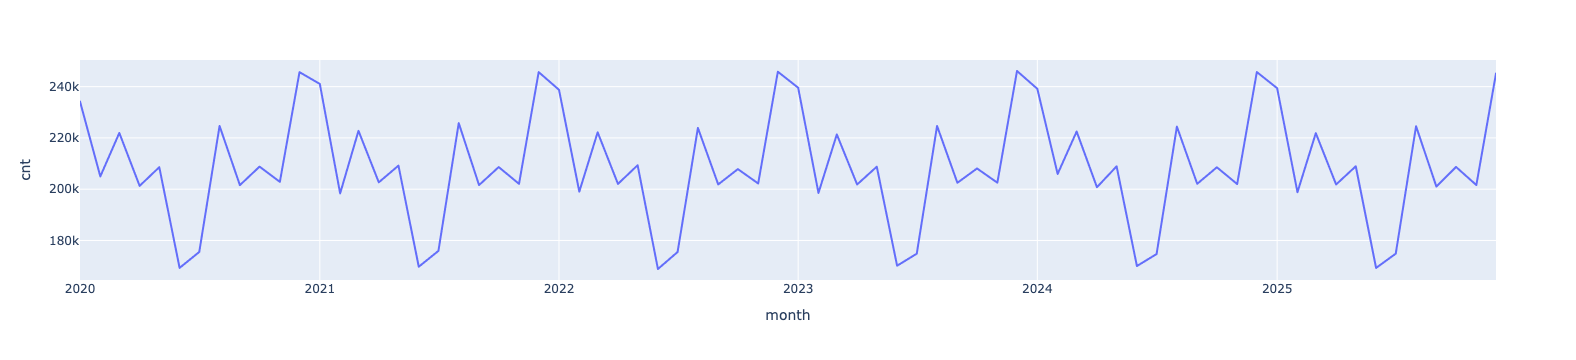

In [4]:
df = duckdb.query(
    """
    SELECT
        date_trunc('month', order_date) AS month,
        count(amount) AS cnt
    FROM
        orders
    WHERE
        1=1
    GROUP BY 1 
    ORDER BY 1
    """
).df()

fig = px.scatter(
    df, 
    x='month', 
    y='cnt', 
    render_mode='webgl'
)
fig.update_traces(mode='lines')

fig.show()

## Разница дат

У нас есть три разных даты:
- `order_date` — дата оформления заказа
- `shipped_date` — дата доставки заказа
- `receipt_date` — дата получения заказа

### Сдвиг дат по `order_date`, `shipped_date` и `receipt_date`

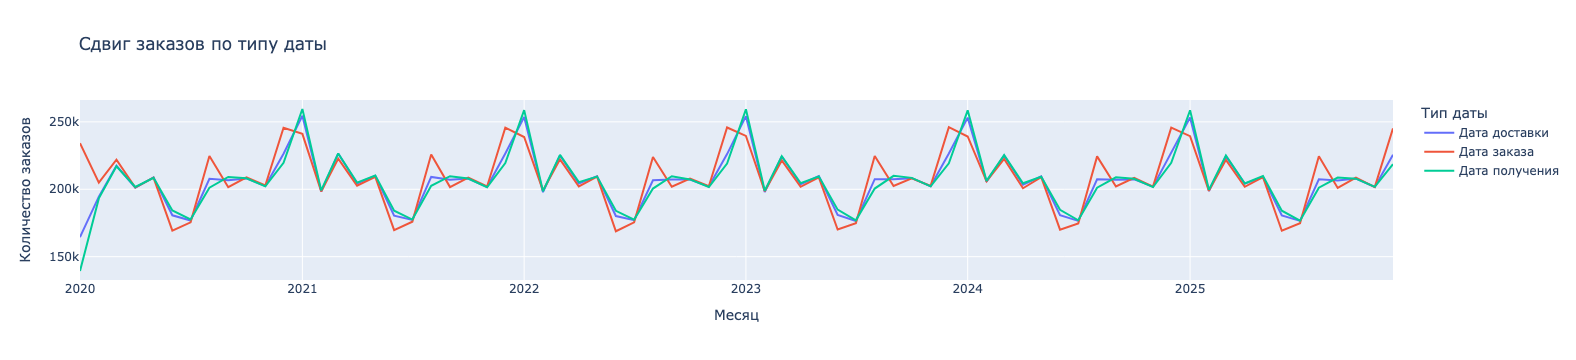

In [5]:
df = duckdb.query(
    """
    SELECT date_trunc('month', order_date) AS month, 'Дата заказа' AS date_type, count(*) AS cnt
    FROM orders
    GROUP BY 1

    UNION ALL

    SELECT date_trunc('month', shipped_date) AS month, 'Дата доставки' AS date_type, count(*) AS cnt
    FROM orders
    WHERE 1=1
        AND shipped_date < '2026-01-01'
    GROUP BY 1

    UNION ALL

    SELECT date_trunc('month', receipt_date) AS month, 'Дата получения' AS date_type, count(*) AS cnt
    FROM orders
    WHERE 1=1
        AND receipt_date < '2026-01-01'
    GROUP BY 1

    ORDER BY 1, 2
    """
).df()

fig = px.line(
    df,
    x='month',
    y='cnt',
    color='date_type',
    labels={
        'month': 'Месяц',
        'cnt': 'Количество заказов',
        'date_type': 'Тип даты'
    },
    title='Сдвиг заказов по типу даты'
)
fig.show()

### Сдвиг дат по `shipped_date` и `receipt_date`

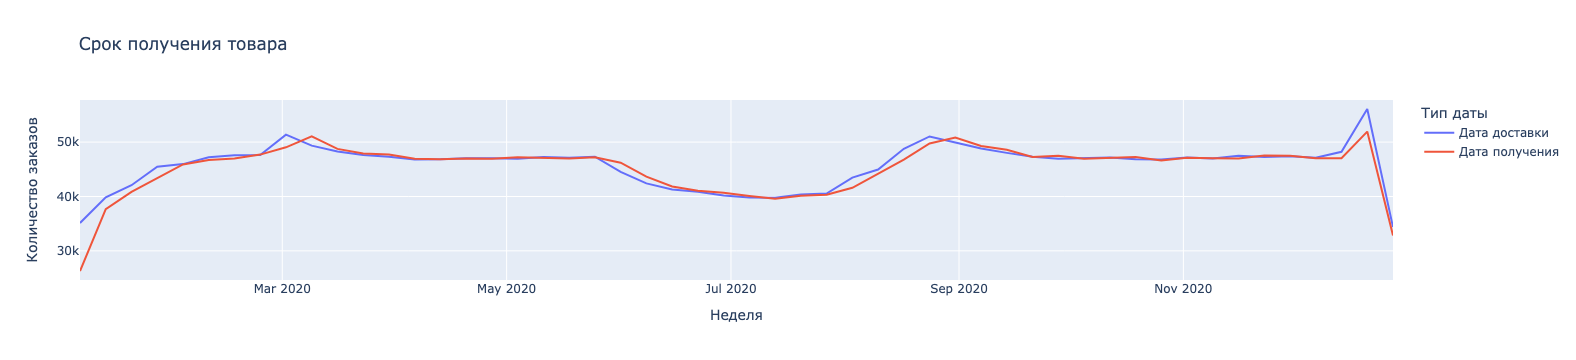

In [6]:
df = duckdb.query(
    """
    SELECT week, date_type, cnt
    FROM (
        SELECT date_trunc('week', shipped_date) AS week, 'Дата доставки' AS date_type, count(*) AS cnt
        FROM orders
        WHERE shipped_date >= '2020-01-01' AND shipped_date < '2021-01-01'
        GROUP BY 1

        UNION ALL

        SELECT date_trunc('week', receipt_date) AS week, 'Дата получения' AS date_type, count(*) AS cnt
        FROM orders
        WHERE receipt_date >= '2020-01-01' AND receipt_date < '2021-01-01'
        GROUP BY 1
    )
    WHERE week >= '2020-01-01' AND week < '2021-01-01'
    ORDER BY 1, 2
    """
).df()

fig = px.line(
    df,
    x='week',
    y='cnt',
    color='date_type',
    labels={
        'week': 'Неделя',
        'cnt': 'Количество заказов',
        'date_type': 'Тип даты'
    },
    title='Срок получения товара'
)
fig.show()

### Средний срок доставки заказа

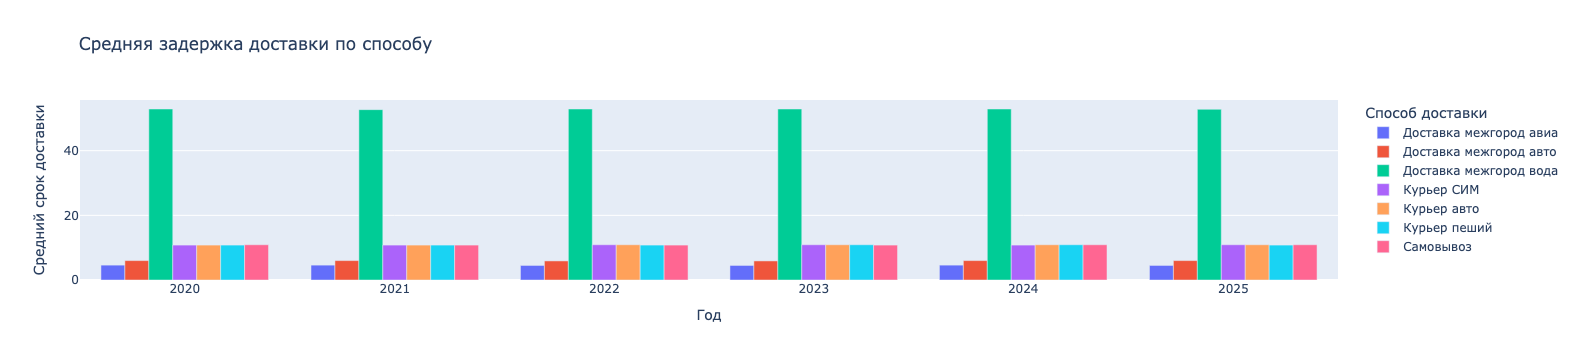

In [7]:
df = duckdb.query(
    """
    SELECT
        date_trunc('year', order_date) AS year,
        ship_name,
        ROUND(AVG(EPOCH(shipped_date - order_date)) / 86400, 1) AS avg_delay_days
    FROM orders AS o
    JOIN ship_types AS st USING (ship_id)
    WHERE
        1=1
    GROUP BY 1, 2
    ORDER BY 1, 2
    """
).df()

fig = px.bar(
    df,
    x='year',
    y='avg_delay_days',
    color='ship_name',
    barmode='group',  # grouped — столбцы рядом, не стопкой
    labels={
        'year': 'Год',
        'avg_delay_days': 'Средний срок доставки',
        'ship_name': 'Способ доставки'
    },
    title='Средняя задержка доставки по способу'
)
fig.show()